# Q4.
```{admonition}
:class: note
Generate a simulated two-class data set with $100$ observations and two features in which there is a visible but non-linear separation between the two classes. Show that in this setting, a support vector machine with a polynomial kernel (with degree greater than $1$) or a radial kernel will outperform a support vector classifier on the training data. Which technique performs best on the test data? Make plots and report training and test error rates in order to back up your assertions.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [4]:
rng = np.random.default_rng(1729)
xs = rng.normal(0,1,100)
xs[xs>1] += 2
xs[xs<-1] -= 2

ys = rng.normal(0,1,100)

feats = np.column_stack([xs,ys])
classes = (np.abs(xs)<2).astype(int)

df = pd.DataFrame({'x':xs,'y':ys,'class':classes})

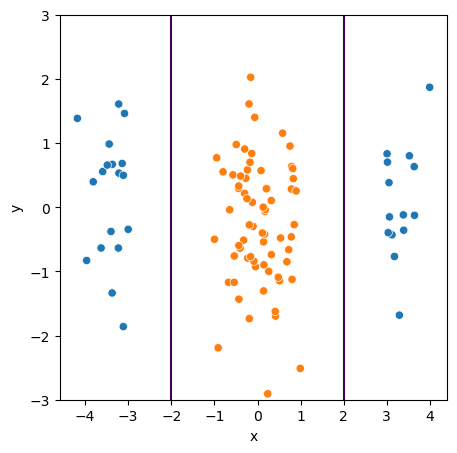

In [5]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x',y='y',hue='class',legend=False)

xx, yy = np.linspace(-3,3), np.linspace(-3,3)
XX, YY = np.meshgrid(xx,yy)
plot_df = pd.DataFrame({'x':XX.ravel(),'y':YY.ravel()})

Z = np.abs(XX)

plt.contour(XX,YY,Z,levels=[2])

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df[['x','y']],df['class'],shuffle=True,random_state=1728)

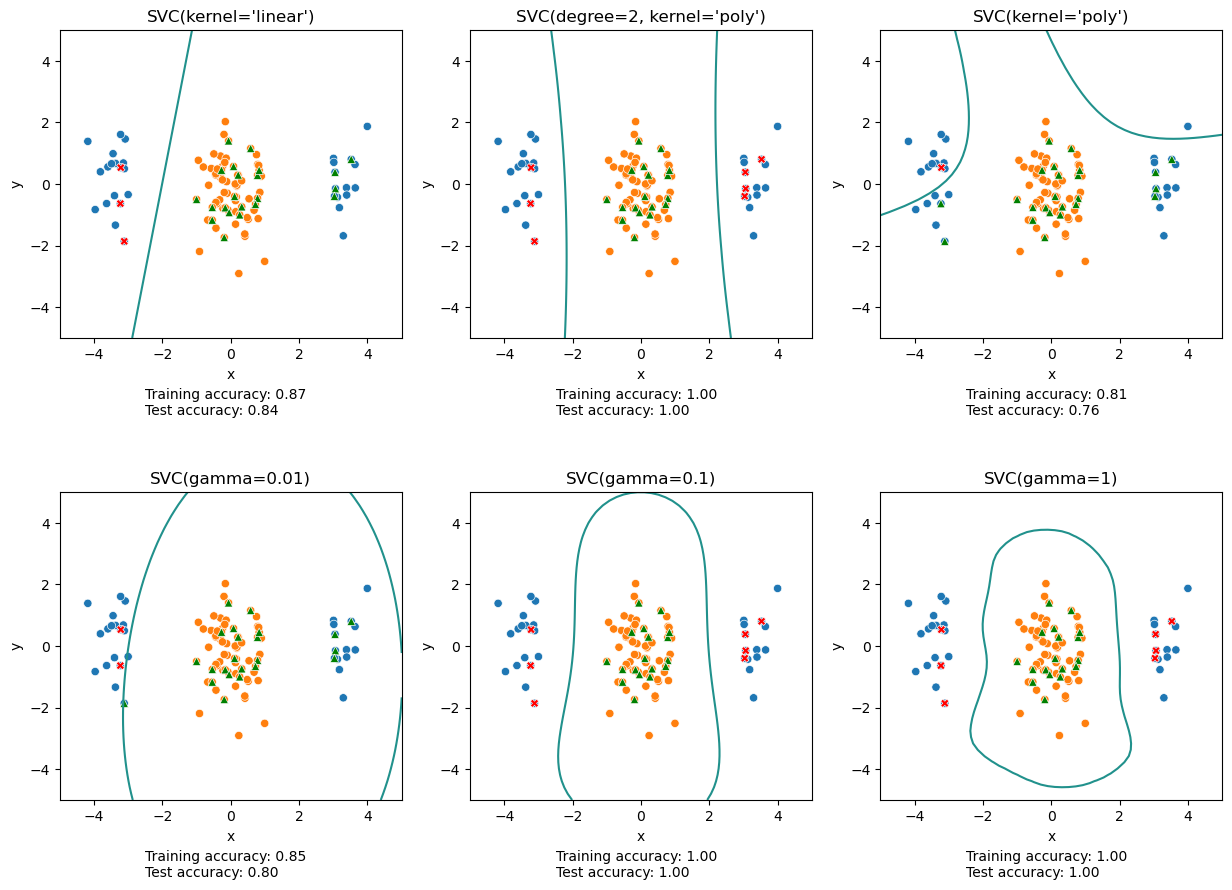

In [7]:
fig, ax = plt.subplots(2,3,figsize=(15,10))
plt.subplots_adjust(hspace=0.5)
ax = ax.flatten()

xx, yy = np.linspace(-5,5), np.linspace(-5,5)
XX, YY = np.meshgrid(xx,yy)
plot_df = pd.DataFrame({'x':XX.ravel(),'y':YY.ravel()})

models = [svm.SVC(kernel='linear'),svm.SVC(kernel='poly',degree=2),svm.SVC(kernel='poly',degree=3),svm.SVC(kernel='rbf',gamma=0.01),svm.SVC(kernel='rbf',gamma=0.1),svm.SVC(kernel='rbf',gamma=1)]
for i, method in enumerate(models):
    method.fit(X_train,y_train)
    method_train_preds, method_test_preds = method.predict(X_train), method.predict(X_test)
    method_train_acc, method_test_acc = accuracy_score(method_train_preds,y_train), accuracy_score(method_test_preds,y_test)
    
    Z = method.decision_function(plot_df).reshape(XX.shape)
#    df2 = pd.DataFrame({'x':xs,'y':ys})
    
    sns.scatterplot(data=df,x='x',y='y',hue='class',legend=False,ax=ax[i])
    sns.scatterplot(x=X_test['x'],y=X_test['y'],style=method.predict(X_test),hue=method.predict(X_test),palette={0:'red',1:'green'},markers={0:'X',1:'^'},ax=ax[i],legend=False)
    ax[i].contour(XX,YY,Z,levels=0)
    ax[i].text(0.25,-0.25,f'Training accuracy: {method_train_acc:.2f}\nTest accuracy: {method_test_acc:.2f}',transform=ax[i].transAxes)
    ax[i].set_title(f'{method}')

plt.show()